In [10]:
##Imports and setup to train baseline models
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
#preprocessed data
train_df = pd.read_csv('../data/processed/train_final.csv')
test_df = pd.read_csv('../data/processed/test_final.csv')
bc_lambda = joblib.load('../models/bc_lambda.pkl')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (15771, 48)
Test shape: (3930, 48)


In [15]:
#baseline model experiment
#reusable helper function
def safe_inv_boxcox(y_pred, lmbda, max_reasonable=1500):
    """
    Safely invert a Box-Cox transform, clipping predictions to avoid
    domain errors (negative base with fractional exponent) and
    unrealistic extrapolated values.

    Parameters
    ----------
    y_pred : array-like
        Predictions in Box-Cox transformed space.
    lmbda : float
        The fitted Box-Cox lambda parameter.
    max_reasonable : float
        Upper sanity bound for inverted predictions (Wh).

    Returns
    -------
    ndarray
        Predictions inverted back to the original Wh scale.
    """
    if lmbda != 0:
        valid = np.clip(1 + lmbda * y_pred, a_min=1e-6, a_max=None)
        result = valid ** (1 / lmbda)
    else:
        result = np.exp(y_pred)
    return np.clip(result, a_min=0, a_max=max_reasonable)


def evaluate_predictions(y_true, y_pred, model_name):
    """
    Compute MAE, RMSE, MAPE, and R² for a set of predictions.

    Parameters
    ----------
    y_true : array-like
        Actual target values (original Wh scale).
    y_pred : array-like
        Predicted target values (original Wh scale).
    model_name : str
        Label identifying this model in results tables.

    Returns
    -------
    dict
        Model name and its four evaluation metrics.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-6, None))) * 100
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

In [16]:
#features using
feature_cols = [c for c in train_df.columns if c not in ['date', 'Appliances', 'Appliances_bc']]

X_train = train_df[feature_cols]
y_train = train_df['Appliances_bc']
X_test = test_df[feature_cols]
y_test_actual = test_df['Appliances']

print("Features used:", len(feature_cols))

Features used: 45


In [17]:
#results
results_list = []

# --- Naive persistence baseline ---
naive_pred = test_df['Appliances_lag_1']
results_list.append(evaluate_predictions(test_df['Appliances'], naive_pred, 'Naive'))

# --- Linear Regression ---
lr = LinearRegression().fit(X_train, y_train)
pred_actual = safe_inv_boxcox(lr.predict(X_test), bc_lambda)
results_list.append(evaluate_predictions(y_test_actual, pred_actual, 'Linear Regression'))

# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_actual = safe_inv_boxcox(rf.predict(X_test), bc_lambda)
results_list.append(evaluate_predictions(y_test_actual, pred_actual, 'Random Forest'))

# --- XGBoost ---
xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)
pred_actual = safe_inv_boxcox(xgb_model.predict(X_test), bc_lambda)
results_list.append(evaluate_predictions(y_test_actual, pred_actual, 'XGBoost'))

In [18]:
baseline_results = pd.DataFrame(results_list)
print(baseline_results)

baseline_results.to_csv('../data/processed/baseline_results.csv', index=False)


# ============================================================
# STEP 4.6 — Save trained models
# ============================================================
joblib.dump(rf, '../models/rf_baseline.pkl')
joblib.dump(xgb_model, '../models/xgb_baseline.pkl')
joblib.dump(lr, '../models/lr_baseline.pkl')

print("Baseline models saved.")

               Model        MAE        RMSE       MAPE        R2
0              Naive  26.246819   65.747028  21.898901  0.449627
1  Linear Regression  39.004480  131.875555  26.403592 -1.214287
2      Random Forest  21.467393   52.669068  16.502867  0.646803
3            XGBoost  19.286535   48.798904  15.277149  0.696803
Baseline models saved.


In [22]:
#Linear Regression diagnostic 
import pandas as pd

pred_actual = safe_inv_boxcox(lr.predict(X_test), bc_lambda)
pred_actual = pd.Series(pred_actual)

print(pred_actual.describe())
print("Predictions at max clip (1500):", (pred_actual >= 1499).sum())

count    3930.000000
mean      106.507694
std       170.867392
min        44.183945
25%        57.508887
50%        69.572758
75%        91.993410
max      1500.000000
dtype: float64
Predictions at max clip (1500): 40


### Diagnosing Linear Regression's Negative R²

Inspecting Linear Regression's inverted predictions reveals 40 of 3,930 test predictions (~1%)
hit the safety clip ceiling (1500 Wh) — indicating the raw Box-Cox-space predictions before
inversion were extreme outliers, consistent with unstable coefficients under the multicollinearity
observed among indoor temperature sensors (T1-T9) in EDA. This is further supported by RMSE being
3.4x larger than MAE (131.88 vs 39.00) — since RMSE squares errors, a small number of extreme
mispredictions disproportionately inflate it, exactly the signature of a handful of catastrophic
predictions among otherwise moderate ones. This confirms Linear Regression is structurally unsuited
to this feature set, motivating the shift to regularized tree-based and deep learning models.

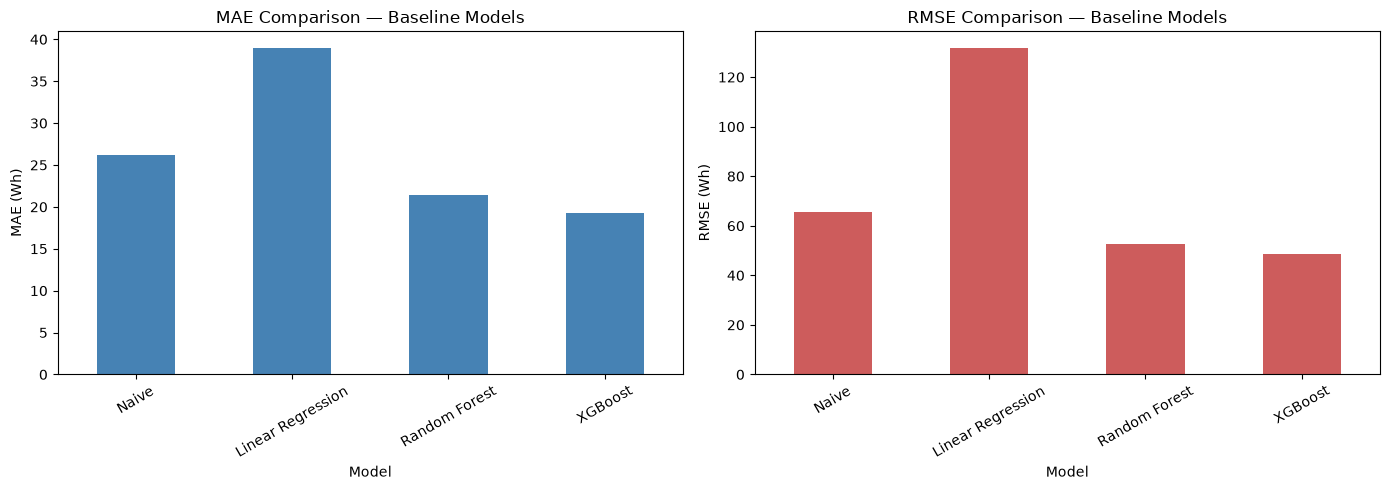

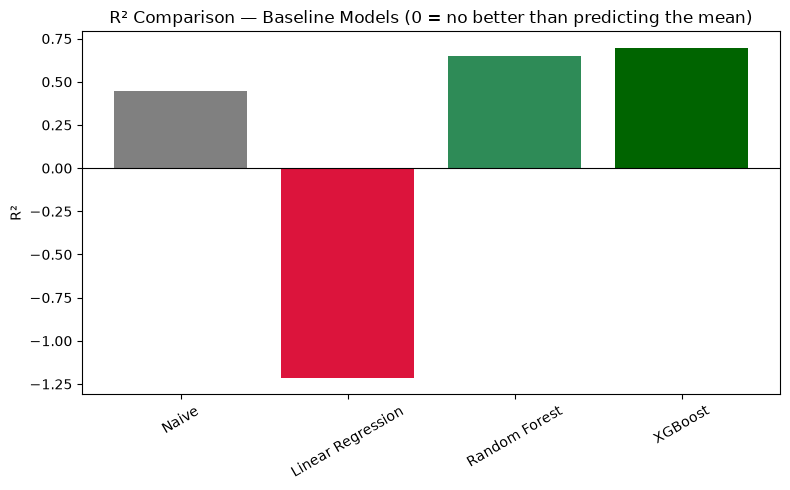

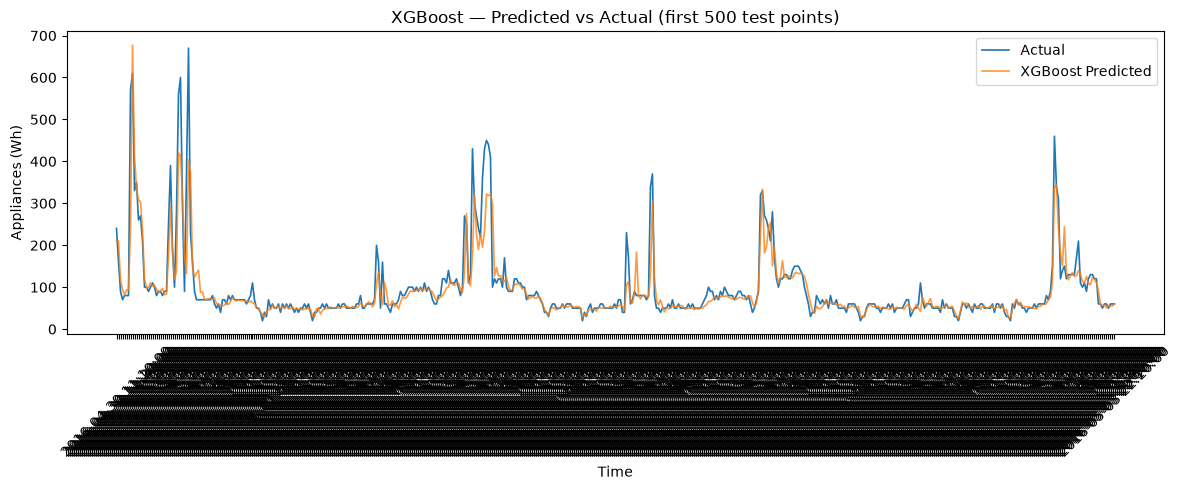

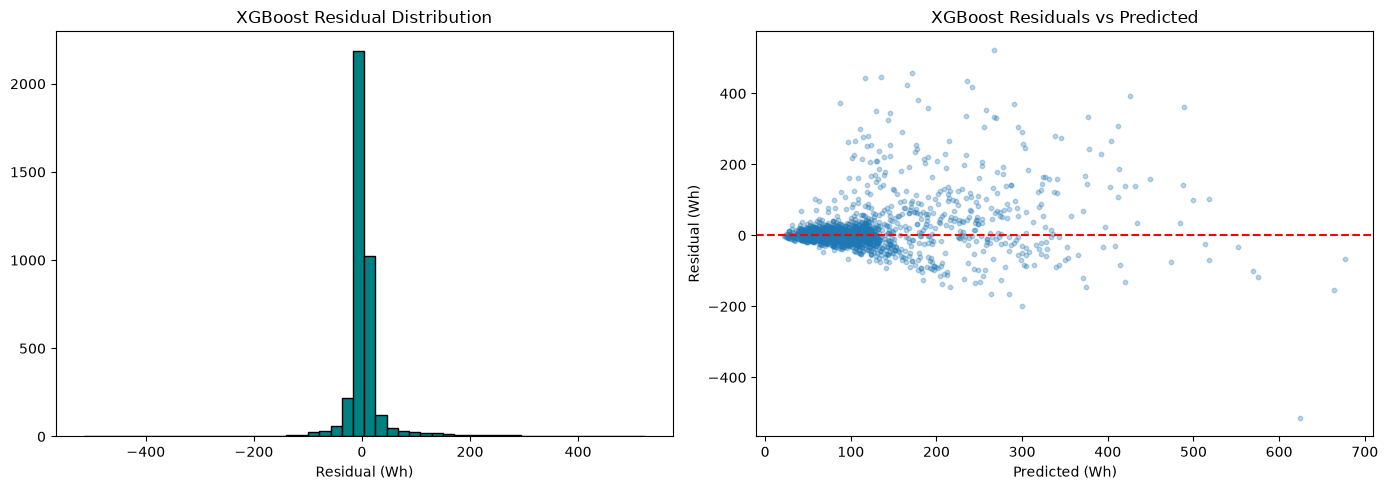

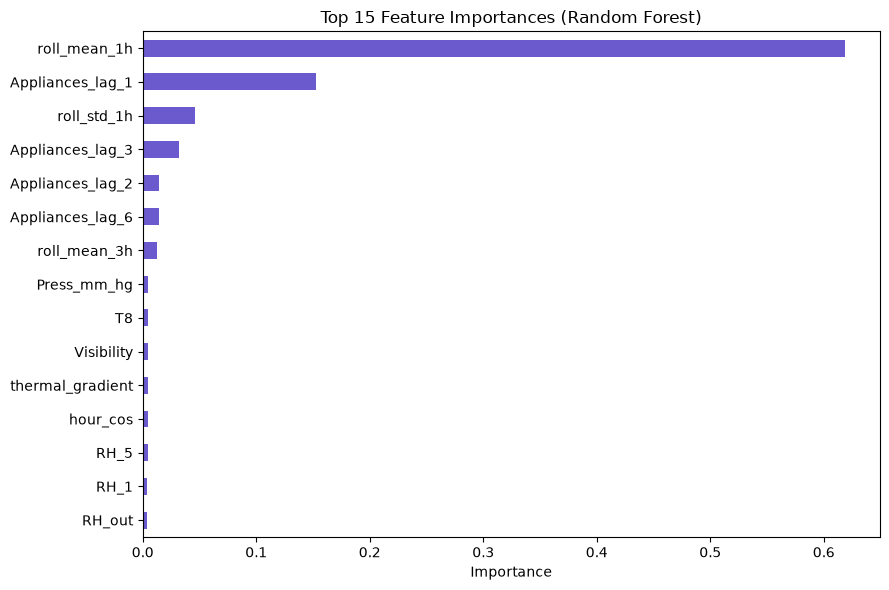

In [23]:
#plots
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# PLOT 1 — Bar chart: MAE & RMSE across all baseline models
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

baseline_results.set_index('Model')['MAE'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('MAE Comparison — Baseline Models')
axes[0].set_ylabel('MAE (Wh)')
axes[0].tick_params(axis='x', rotation=30)

baseline_results.set_index('Model')['RMSE'].plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('RMSE Comparison — Baseline Models')
axes[1].set_ylabel('RMSE (Wh)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../reports/baseline_mae_rmse_comparison.png', dpi=150)
plt.show()


# ============================================================
# PLOT 2 — R² comparison (highlights Linear Regression's failure visually)
# ============================================================
plt.figure(figsize=(8,5))
colors = ['gray', 'crimson', 'seagreen', 'darkgreen']
plt.bar(baseline_results['Model'], baseline_results['R2'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('R² Comparison — Baseline Models (0 = no better than predicting the mean)')
plt.ylabel('R²')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../reports/baseline_r2_comparison.png', dpi=150)
plt.show()


# ============================================================
# PLOT 3 — Predicted vs Actual for best baseline model (XGBoost)
# ============================================================
pred_xgb = safe_inv_boxcox(xgb_model.predict(X_test), bc_lambda)

plt.figure(figsize=(12,5))
plt.plot(test_df['date'].values[:500], y_test_actual.values[:500], label='Actual', linewidth=1.2)
plt.plot(test_df['date'].values[:500], pred_xgb[:500], label='XGBoost Predicted', linewidth=1.2, alpha=0.8)
plt.title('XGBoost — Predicted vs Actual (first 500 test points)')
plt.xlabel('Time')
plt.ylabel('Appliances (Wh)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/xgboost_pred_vs_actual.png', dpi=150)
plt.show()


# ============================================================
# PLOT 4 — Residuals for XGBoost
# ============================================================
residuals = y_test_actual.values - pred_xgb

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].hist(residuals, bins=50, color='teal', edgecolor='black')
axes[0].set_title('XGBoost Residual Distribution')
axes[0].set_xlabel('Residual (Wh)')

axes[1].scatter(pred_xgb, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('XGBoost Residuals vs Predicted')
axes[1].set_xlabel('Predicted (Wh)')
axes[1].set_ylabel('Residual (Wh)')

plt.tight_layout()
plt.savefig('../reports/xgboost_residuals.png', dpi=150)
plt.show()


# ============================================================
# PLOT 5 — Feature importance from Random Forest (from earlier, formatted for report)
# ============================================================
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)

plt.figure(figsize=(9,6))
importances.plot(kind='barh', color='slateblue')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150)
plt.show()